# BEE 4750 Lab 2: Monte Carlo

**Name**: Adrián Cardona Young

**ID**: 5361635

> **Due Date**
>
> Thursday, 10/02/25, 9:00pm

## Setup

The following code should go at the top of most Julia scripts; it will
load the local package environment and install any needed packages. You
will see this often and shouldn’t need to touch it.

In [12]:
import Pkg
Pkg.activate(".")
Pkg.instantiate()

  Activating project at `c:\Users\adric\OneDrive - Cornell University\Documents\3. Env Sys Analysis\lab-2-adricardona-bit`


In [119]:
using Random # random number generation
using Distributions # probability distributions and interface
using Statistics # basic statistical functions, including mean
using Plots # plotting
using Plots.PlotMeasures

## Overview

In this lab, we will conduct a Monte Carlo experiment and explore how
sensitive Monte Carlo estimates are to the underlying probability
distribution(s).

You should always start any computing with random numbers by setting a
“seed,” which controls the sequence of numbers which are generated
(since these are not *really* random, just “pseudorandom”). In Julia, we
do this with the `Random.seed!()` function.

In [14]:
Random.seed!(1)

TaskLocalRNG()

It doesn’t matter what seed you set, though different seeds might result
in slightly different values. But setting a seed means every time your
notebook is run, the answer will be the same.

> **Seeds and Reproducing Solutions**
>
> If you don’t re-run your code in the same order or if you re-run the
> same cell repeatedly, you will not get the same solution. If you’re
> working on a specific problem, you might want to re-use
> `Random.seed()` near any block of code you want to re-evaluate
> repeatedly.

### Probability Distributions and Julia

Julia provides a common interface for probability distributions with the
[`Distributions.jl`
package](https://juliastats.org/Distributions.jl/stable/). The basic
workflow for sampling from a distribution is:

1.  Set up the distribution. The specific syntax depends on the
    distribution and what parameters are required, but the general call
    is the similar. For a normal distribution or a uniform distribution,
    the syntax is

    ``` julia
    # you don't have to name this "normal_distribution"
    # μ is the mean and σ is the standard deviation
    normal_distribution = Normal(μ, σ)
    # a is the upper bound and b is the lower bound; these can be set to +Inf or -Inf for an unbounded distribution in one or both directions.
    uniform_distribution = Uniform(a, b)
    ```

    There are lots of both
    [univariate](https://juliastats.org/Distributions.jl/stable/univariate/#Index)
    and
    [multivariate](https://juliastats.org/Distributions.jl/stable/multivariate/)
    distributions, as well as the ability to create your own, but we
    won’t do anything too exotic here.

2.  Draw samples. This uses the `rand()` command (which, when used
    without a distribution, just samples uniformly from the interval
    $[0, 1]$.) For example, to sample from our normal distribution
    above:

    ``` julia
    # draw n samples
    rand(normal_distribution, n)
    ```

Putting this together, let’s say that we wanted to simulate 100
six-sided dice rolls. We could use a [Discrete Uniform
distribution](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.DiscreteUniform).

In [15]:
dice_dist = DiscreteUniform(1, 6) # can generate any integer between 1 and 6
dice_rolls = rand(dice_dist, 100) # simulate rolls

100-element Vector{Int64}:
 1
 3
 5
 4
 6
 2
 5
 5
 5
 2
 ⋮
 3
 6
 5
 5
 6
 3
 6
 6
 6

And then we can plot a histogram of these rolls:

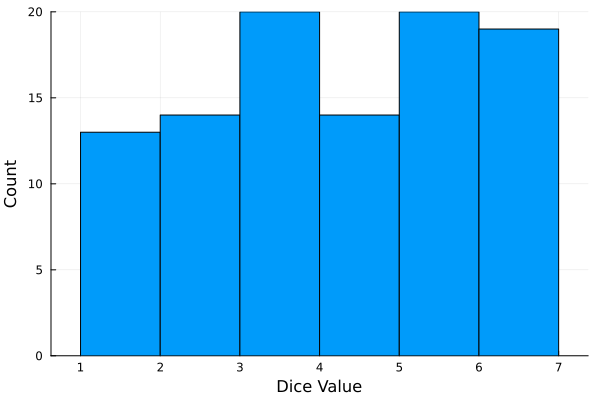

In [16]:
histogram(dice_rolls, legend=:false, bins=6)
ylabel!("Count")
xlabel!("Dice Value")

### Instructions

**Remember to**:

-   Evaluate all of your code cells, in order (using a `Run All`
    command). This will make sure all output is visible and that the
    code cells were evaluated in the correct order.
-   Tag each of the problems when you submit to Gradescope; a 10%
    penalty will be deducted if this is not done.

## Problem

A common engineering problem is to quantify flood risk, which is
typically computed by propagating a flood hazard distribution through a
*depth-damage function* relating flood depths to economic damages. A
reasonable depth-damage function for a house without a basement is a
bounded logistic function,
$$d(h) = \mathbb{1}_{h > 0} \frac{L}{1 + \exp(-k (h - h_0))},$$

where $d$ is the damage as a percent of total structure value, $h$ is
the water depth (relative to the house’s ground floor elevation) in m,
$\mathbb{1}_{x > 0}$ is the indicator function, $L$ is the maximum loss
in USD, $k$ is the slope of the depth-damage relationship, and $h_0$ is
the inflection point. We’ll assume $L=\$200,000$, $k=0.8$, and $h_0=3$.

For this problem, suppose that we have two different probability
distributions characterizing annual maxima flood depths:

1.  $h \sim LogNormal(1.2, 0.3)$;
2.  $h \sim GeneralizedExtremeValue(3, 0.9, -0.15)$.

Plot histograms of samples from these distributions and conduct a Monte
Carlo experiment for annual maximum flood damages using each. Answer the
following questions:

-   What are the Monte Carlo estimates of the expected value and the 99%
    quantile for the annual maximum damage the structure would suffer
    for each of these flood hazard distributions?
-   How did you decide on your sample size?
-   Why do you think the estimates differed or did not differ (you can
    also plot the depth-damage function to compare with the samples)?
-   How might you decide (based on getting additional information, if
    needed) which distribution is “better”?

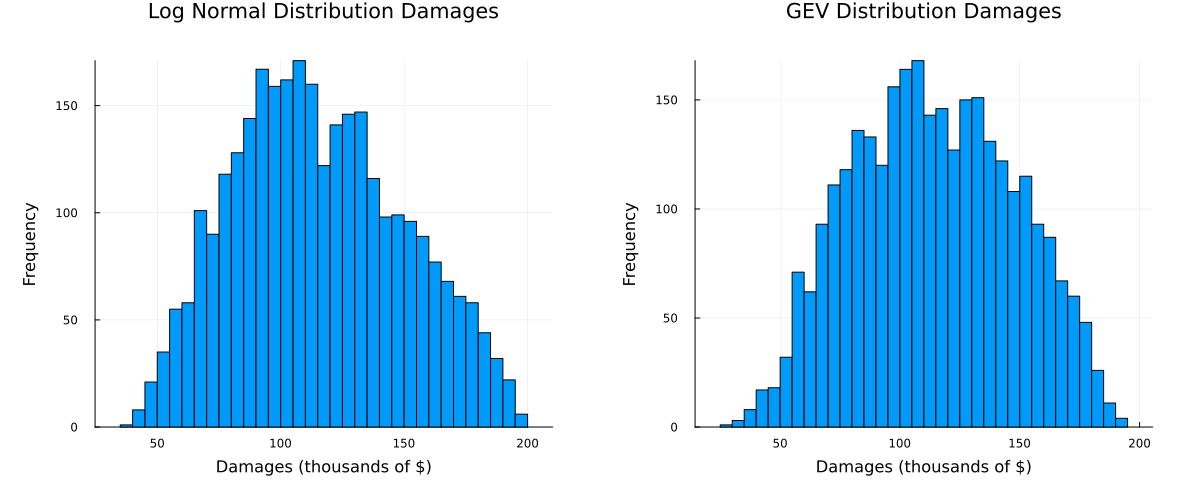

In [148]:
#Histograms
#1)

L = 200_000
k = 0.8
h0 = 3
n = 3000 #sample size

function indicator(h)
    if h < 0
        return 0
    elseif h > 0
        return 1
    end
end

function pdfhist(l, k, h0, n)
    #generating h values for Log Normal distribution
    lognorm = LogNormal(1.2, 0.3)
    hone = rand(lognorm, n)

    #generating h values for generalized extreme value distribution
    gev = GeneralizedExtremeValue(3, 0.9, -0.15)
    htwo = rand(gev, n)

    #calculating damage values for each height for each distribution
    damageone = zeros(n)
    for i=1:n
        damageone[i] = indicator(hone[i]) * l/(1 + exp(-k*(hone[i]-h0)))
    end

    damagetwo = zeros(n)
    for i=1:n
        damagetwo[i] = indicator(htwo[i]) * l/(1 + exp(-k*(htwo[i]-h0)))
    end
    return hone, htwo, damageone, damagetwo
end

h1, h2, d1, d2 = pdfhist(L, k, h0, n)

p1 = histogram(d1, legend=:false, title="Log Normal Distribution Damages", xlabel="Damages (thousands of \$)", ylabel="Frequency", xformatter=x->round(Int64, x/1000), bins=50)
p2 = histogram(d2, legend=:false, title="GEV Distribution Damages", xlabel="Damages (thousands of \$)", ylabel="Frequency", xformatter=x->round(Int64, x/1000), bins=50)

plot(p1, p2, layout=(1,2), size=(1200, 500), margins=10mm)

-   What are the Monte Carlo estimates of the expected value and the 99%
    quantile for the annual maximum damage the structure would suffer
    for each of these flood hazard distributions?
-   How did you decide on your sample size?
-   Why do you think the estimates differed or did not differ (you can
    also plot the depth-damage function to compare with the samples)?
-   How might you decide (based on getting additional information, if
    needed) which distribution is “better”?

In [53]:
println(string("Expected Value LogNormal Distribution: \$", round(Int, mean(d1))))
println(string("Expected Value GEV Distribution: \$", round(Int, mean(d2))))

println(string("99th Percentil LogNormal Distribution: \$", round(Int, quantile!(d1, 0.99))))
println(string("99th Percentil GEV Distribution: \$", round(Int, quantile!(d2, 0.99))))

Expected Value LogNormal Distribution: $114983
Expected Value GEV Distribution: $113562
99th Percentil LogNormal Distribution: $189352
99th Percentil GEV Distribution: $183210


In [56]:
expsone = zeros(10_000)
expstwo = zeros(10_000)
for i in 1:10_000
    a1, a2 = pdfhist(L, k, h0, i)
    expsone[i] = mean(a1)
    expstwo[i] = mean(a2)
end

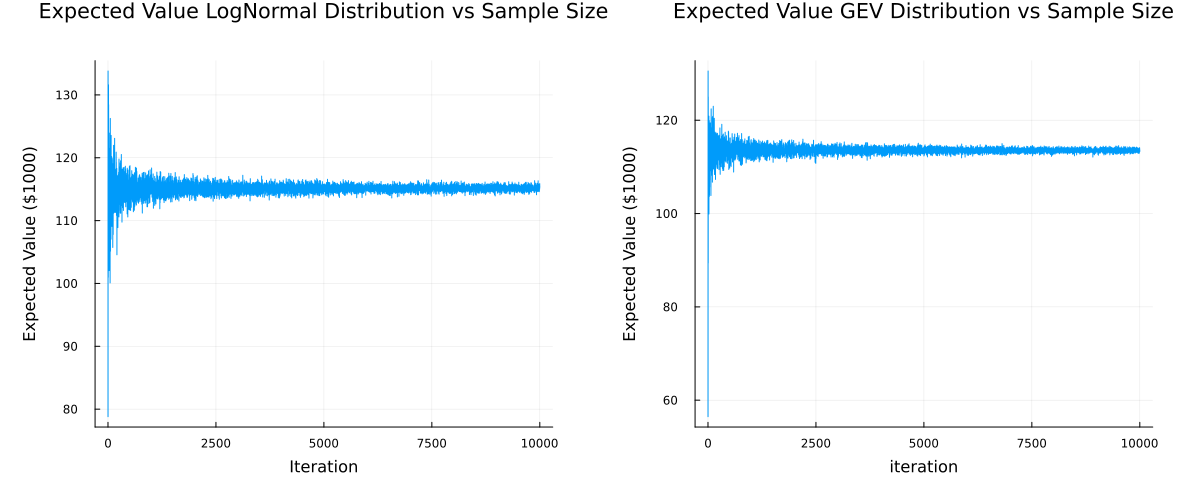

In [140]:
dem1 = plot(1:10000, expsone, xlabel="Iteration", ylabel="Expected Value (\$1000)", title="Expected Value LogNormal Distribution vs Sample Size", yformatter=y->round(Int64, y/1000), legend=:false)
dem2 = plot(1:10000, expstwo, xlabel="iteration", ylabel="Expected Value (\$1000)", title="Expected Value GEV Distribution vs Sample Size", yformatter=y->round(Int64, y/1000), legend=:false)

plot(dem1, dem2, layout=(1, 2), size=(1200, 500), margins=10mm)

Both distributions reach a stable expected value by around 1000 iterations. Used 3000 iterations in results above for redundancy

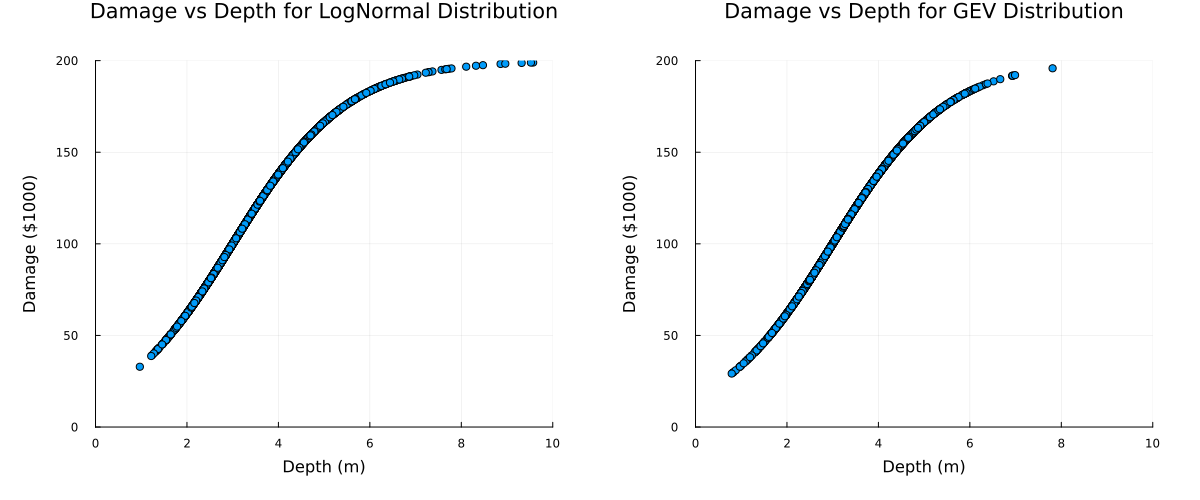

In [141]:
dem3 = scatter(h1, d1, xlabel="Depth (m)", ylabel="Damage (\$1000)", title="Damage vs Depth for LogNormal Distribution", xlims=(0, 10), ylims=(0, 200000), yformatter=y->round(Int64, y/1000), legend=:false)
dem4 = scatter(h2, d2, xlabel="Depth (m)", ylabel="Damage (\$1000)", title="Damage vs Depth for GEV Distribution", xlims=(0, 10), ylims=(0, 200000), yformatter=y->round(Int64, y/1000), legend=:false)

plot(dem3, dem4, layout=(1, 2), size=(1200, 500), margins=10mm)

Both Distributions have similar values for the means and 99th percentiles, suggesting that the results don't vary that much between the two distributions. However, the GEV distribution is spread over narrower numbers. It has a maximum of about 8 feet of depth and a minimum below 0.5. Meanwhile the LogNormal distribution has value up to 10 and down to only 0.5. In this way the GEV doesn't have floods quite as high as the LogNormal.

A good distribution has sufficient data points for each possible depth of flood. That is, we don't want there to be few points at either the lower, middle range, or higher end of the values possible.

## References

Put any consulted sources here, including classmates you worked with/who
helped you.